[<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/> Deep Q-Learning (LunarLander)](https://colab.research.google.com/github/AlbertoLopezCorbalan/eml-albertolopezc/blob/main/Entornos_Complejos/deep_q_learning.ipynb)  

# **Deep-Q-Learning con Políticas epsilon_greedy**

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de **Deep Q-Learning (DQN)** con políticas **ε-greedy con decaimiento**. El propósito de este análisis es entrenar un agente en un entorno de *gymnasium* con el entorno **LunarLander-v3**, un problema en el que el agente debe aprender a controlar un módulo de aterrizaje para que descienda y aterrice de forma estable y segura sobre una superficie lunar. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.


    Author: Alberto López Corbalán
    Email: alberto.lopezc@um.es
    Date: 2026/06/08

## Configuración del entorno

Si el notebook se está ejecutando en Google Colab, clona el repositorio del proyecto e instala las dependencias necesarias. Además, añade la carpeta `src` al `PYTHONPATH` para permitir la importación de módulos propios.

In [1]:
!pip install "gymnasium[toy-text]"
!pip install "gymnasium[box2d]"

In [2]:
import sys

if "google.colab" in sys.modules:
    print("Google Colab")
    !git clone https://github.com/AlbertoLopezCorbalan/eml-albertolopezc
    %cd eml-albertolopezc/Entornos_Complejos

sys.path.append("src")
print(sys.path)

['C:\\Users\\Alberto\\anaconda3\\envs\\EML\\python311.zip', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\DLLs', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML', '', 'C:\\Users\\Alberto\\anaconda3\\envs\\EML\\Lib\\site-packages', 'src']


## Importación de dependencias
Se importan las librerías y módulos necesarios para la simulación de problemas de bandits multi-brazo.

In [3]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from tqdm import tqdm
import gymnasium as gym
from agent.deep_q_learning import DeepQLearning
from plotting import plot_stats, plot_episode_lengths
from IPython.display import HTML
import time
import random

seed = 123 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
random.seed(seed) # semilla del generador aleatorio

## Experimento

El diseño del agente consta de dos componentes principales: el algoritmo de aprendizaje encargado de estimar la calidad de las acciones mediante una red neuronal que aproxima la función de valor acción-estado $Q(s,a)$, y la política empleada para seleccionar dichas acciones.

* **Política del agente**

  * **Política $\epsilon$-greedy con decaimiento**: el agente selecciona, con probabilidad $\epsilon$, una acción aleatoria para explorar el entorno y, con probabilidad $1-\epsilon$, la acción con mayor valor estimado por la red neuronal para explotar el conocimiento adquirido. El valor de $\epsilon$ disminuye progresivamente durante el entrenamiento, favoreciendo la exploración en las primeras etapas y la explotación en fases posteriores.

* **Algoritmo de aprendizaje**

  * Se implementa un algoritmo de **Deep Q-Learning (DQN)** aplicado al entorno **LunarLander-v3**, basado en la formulación clásica de Q-learning con aproximación mediante redes neuronales.

  * El agente aprende una aproximación de la función $Q(s,a)$ mediante una red neuronal entrenada con experiencias muestreadas de un **replay buffer**, lo que reduce la correlación entre muestras consecutivas.

  * La actualización se realiza minimizando el error cuadrático entre la predicción y el objetivo de Q-learning:

    $$
    y_t = r_t + \gamma \max_a Q(s_{t+1}, a)
    $$

  * El aprendizaje es *off-policy*, ya que la política $\epsilon$-greedy se utiliza para explorar el entorno, mientras que la actualización se basa en la acción óptima estimada en el siguiente estado.

El proceso de entrenamiento seguido por el agente Deep Q-Learning se resume en el siguiente algoritmo de aprendizaje:

**Entrada:** Entorno LunarLander-v3 (E), agente DQN (M), número de episodios (N), factor de descuento ($\gamma$), tasa de aprendizaje ($\alpha$), tamaño del replay buffer, parámetros de exploración ($\epsilon_0$, $\epsilon_{min}$, decay).

**Salida:** Recompensas por episodio y longitudes de episodio.

* Inicializar el entorno (E), la red neuronal $Q_{\theta}$ y el replay buffer.
* Para cada episodio $e \in {1,\dots,N}$:

  * Reiniciar el entorno y obtener el estado inicial $s_0$.
  * Mientras el episodio no haya finalizado:

    * Seleccionar una acción $a_t$ utilizando la política $\epsilon$-greedy sobre $Q_{\theta}$.
    * Ejecutar $a_t$ en el entorno.
    * Observar la recompensa $r_t$, el siguiente estado $s_{t+1}$ y si el episodio ha terminado.
    * Almacenar la transición $(s_t, a_t, r_t, s_{t+1}, done)$ en el replay buffer.
    * Sacar un batch del replay buffer.
    * Calcular el objetivo de Q-learning.
    * Actualizar los parámetros de la red .
  * Al finalizar el episodio:

    * Aplicar el decaimiento del parámetro de exploración $\epsilon$.
    * Registrar la recompensa total y la longitud del episodio.


In [4]:
# continuous=False para que el output sea discreto
# enable_wind = True para que haya mayor dificultad en la navegación
env = gym.make("LunarLander-v3", render_mode="rgb_array", continuous=False, gravity=-10.0, enable_wind=True, wind_power=2.5, turbulence_power=0)

num_episodes = 1500

deep_q_learning_agent = DeepQLearning(env=env, learning_rate=0.0005, initial_epsilon=1.0, epsilon_decay= 0.001, final_epsilon=0.05, discount_factor=0.99)


episode_lengths = []
list_stats = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset(seed=seed)
    done = False
    
    episode_reward = 0
    episode_length = 0
    
    while not done:
        action = deep_q_learning_agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        deep_q_learning_agent.update(state, next_state, action, reward, terminated, truncated)
        state = next_state
        
        done = terminated or truncated
        episode_reward += reward
        episode_length += 1
    
    # Fin de episodio
    deep_q_learning_agent.end_episode()
    deep_q_learning_agent.decay_exploration()

    # Se guardan los promedios y la longitud del episodio para las gráficas posteriores
    list_stats.append(episode_reward)
    episode_lengths.append(episode_length)

    if episode % 50 == 0 and episode != 0:
        print(f" Recompensa del episodio: {episode_reward:.2f}, epsilon: {deep_q_learning_agent.epsilon:.3f}")

  3%|██▋                                                                             | 51/1500 [00:13<06:55,  3.49it/s]

 Recompensa del episodio: -304.63, epsilon: 0.949


  7%|█████▎                                                                         | 101/1500 [00:28<06:24,  3.64it/s]

 Recompensa del episodio: -91.18, epsilon: 0.899


 10%|███████▉                                                                       | 151/1500 [00:43<06:08,  3.66it/s]

...

 93%|████████████████████████████████████████████████████████████████████████▊     | 1401/1500 [32:22<01:06,  1.49it/s]

 Recompensa del episodio: 251.40, epsilon: 0.050


 97%|███████████████████████████████████████████████████████████████████████████▍  | 1451/1500 [33:12<00:41,  1.18it/s]

 Recompensa del episodio: 283.88, epsilon: 0.050


100%|██████████████████████████████████████████████████████████████████████████████| 1500/1500 [33:47<00:00,  1.35s/it]


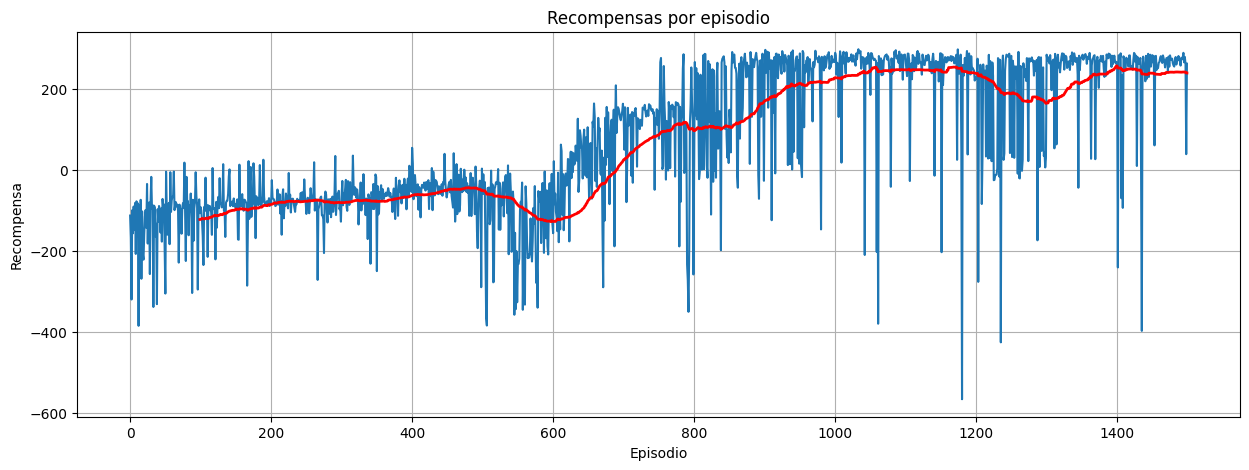

Máxima proporcion: 298.6133410143018


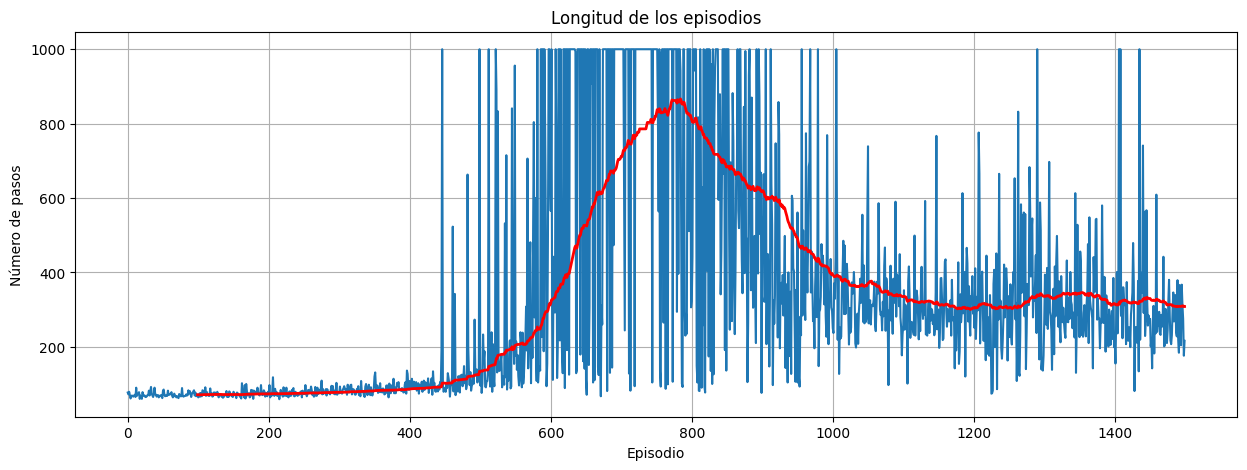

In [5]:
plot_stats(list_stats)
print(f"Máxima proporcion: {max(list_stats)}")
plot_episode_lengths(episode_lengths)

Durante los primeros episodios se observan recompensas claramente negativas. Este comportamiento es esperable, ya que el agente de **Deep Q-Learning (DQN)** comienza el entrenamiento sin conocimiento previo del entorno **LunarLander-v3**, lo que provoca aterrizajes inestables y acciones poco coordinadas bajo una política inicialmente muy exploratoria ($\epsilon = 1$).

A lo largo del entrenamiento, la recompensa muestra una evolución irregular, incluso en torno al episodio 600 se aprecia una ligera caída en el rendimiento. A partir de ese punto, el agente comienza a mejorar de forma progresiva, incrementando la recompensa media hasta estabilizarse aproximadamente en torno a valores cercanos a 200. Este nivel indica que el agente ha aprendido una política efectiva para lograr aterrizajes exitosos en el entorno.

Sin embargo, el entrenamiento presenta **alta variabilidad (fluctuaciones significativas)** a lo largo de todo el proceso. Estas oscilaciones pueden ser provocadas por la exploración residual ($\epsilon$-greedy).

---

## Conclusiones

En conjunto, los resultados muestran que el algoritmo **Deep Q-Learning** es capaz de aprender a resolver el entorno **LunarLander-v3**, aunque con una dinámica de entrenamiento más inestable que métodos tabulares o basados en diferencias temporales simples.

El agente parte de un comportamiento aleatorio con recompensas negativas, sufre una fase intermedia de inestabilidad, y finalmente converge hacia una política funcional que logra recompensas cercanas a 200.

A pesar de la variabilidad en el entrenamiento, el uso de una política $\epsilon$-greedy con decaimiento permite mejorar progresivamente el rendimiento del agente, consolidando estrategias efectivas de aterrizaje en las últimas etapas del aprendizaje.

---

## Simulación del agente entrenado

Una vez finalizado el proceso de entrenamiento del agente, se realiza una simulación. En esta fase, el agente interactúa con el entorno **LunarLander-v3** utilizando  la política aprendida derivada de la función de valor-acción estimada, es decir, seleccionando siempre la acción con mayor valor $Q(s,a)$ para cada estado (`training=False`).

In [6]:
state, _ = env.reset(seed=seed)
ACTION_NAMES = {0: "DO_NOTHING", 1: "FIRE_MAIN_ENGINE", 2: "FIRE_LEFT_ENGINE", 3: "FIRE_RIGHT_ENGINE"}
actions_taken = []
frames = []
done = False
rewards = 0

while not done:
    frames.append(env.render())
    action = deep_q_learning_agent.get_action(state, training=False) # training False asegura np.argmax(self.q_values[state])
    actions_taken.append(ACTION_NAMES[action])
    state, reward, terminated, truncated, _ = env.step(action)
    rewards += reward
    done = terminated or truncated

print(f"Reward final:{rewards:.2f}")
print("Acciones:", " -> ".join(actions_taken))

Reward final:266.63
Acciones: FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_MAIN_ENGINE -> DO_NOTHING -> DO_NOTHING -> DO_NOTHING -> DO_NOTHING -> FIRE_RIGHT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_MAIN_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> DO_NOTHING -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_MAIN_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_RIGHT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> FIRE_LEFT_ENGINE -> 

In [7]:
# Animación
fig, ax = plt.subplots()
ax.axis("off")
im = ax.imshow(frames[0])
def update(i):
    im.set_array(frames[i])
    return [im]
# blit = True para render más eficiente usando blitting -> https://es.wikipedia.org/wiki/Bit_blit
ani = animation.FuncAnimation(fig, update, frames=len(frames),interval=30, blit=True) 
plt.close(fig)  #  evita que se muestre la primera imagen estática
HTML(ani.to_jshtml())